In [1]:
from oggm import cfg, utils
cfg.initialize()
from oggm import workflow
from oggm import DEFAULT_BASE_URL
DEFAULT_BASE_URL


2024-10-15 13:36:41: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2024-10-15 13:36:41: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2024-10-15 13:36:41: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)


'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'

In [2]:
cfg.PATHS['working_dir'] = utils.gettempdir(dirname='dir', reset=True)
cfg.PATHS['working_dir']

'/tmp/OGGM/dir'

In [3]:
# You can try with or without multiprocessing: with two glaciers, OGGM could run on two processors
cfg.PARAMS['use_multiprocessing'] = True

2024-10-15 13:36:42: oggm.cfg: Multiprocessing switched ON after user settings.


In [4]:
rgi_ids = ['RGI60-06.00291'] 

In [5]:
from oggm import workflow
from oggm import DEFAULT_BASE_URL
DEFAULT_BASE_URL

'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup'

In [6]:
gdirs = workflow.init_glacier_directories(
    rgi_ids,  # which glaciers?
    prepro_base_url=DEFAULT_BASE_URL,  # where to fetch the data?
    from_prepro_level=4,  # what kind of data? 
    prepro_border=80  # how big of a map?
)

2024-10-15 13:36:42: oggm.workflow: init_glacier_directories from prepro level 4 on 1 glaciers.
2024-10-15 13:36:42: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [7]:
type(gdirs), type(gdirs[0])

(list, oggm.utils._workflow.GlacierDirectory)

In [8]:
gdir = gdirs[0]  # take Unteraar glacier
print('Path to the DEM:', gdir.get_filepath('dem'))

Path to the DEM: /tmp/OGGM/dir/per_glacier/RGI60-06/RGI60-06.00/RGI60-06.00291/dem.tif


In [9]:


gdir.rgi_date


2000

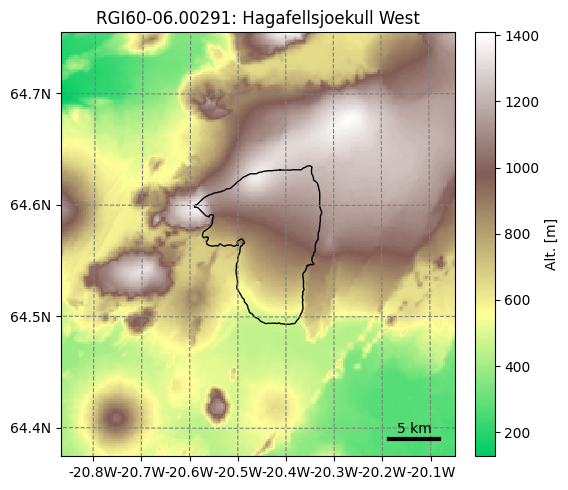

In [10]:
from oggm import graphics
graphics.plot_domain(gdir, figsize=(6, 5))

In [11]:
# Fetch the LOCAL pre-processed directories - note that no arguments are used!
gdirs = workflow.init_glacier_directories(rgi_ids)

2024-10-15 13:36:46: oggm.workflow: Execute entity tasks [GlacierDirectory] on 1 glaciers


In [12]:
gdir.get_filepath('climate_historical')

'/tmp/OGGM/dir/per_glacier/RGI60-06/RGI60-06.00/RGI60-06.00291/climate_historical.nc'

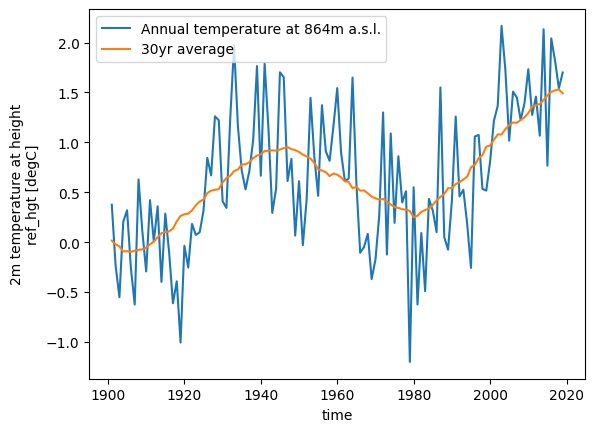

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
# Open the file using xarray
with xr.open_dataset(gdir.get_filepath('climate_historical')) as ds:
    ds = ds.load()
# Plot the data
ds.temp.resample(time='YS').mean().plot(label=f'Annual temperature at {int(ds.ref_hgt)}m a.s.l.');
ds.temp.resample(time='YS').mean().rolling(time=31, center=True, min_periods=15).mean().plot(label='30yr average');
plt.legend();